# ***S100 - Proyecto Final (Grupo N°8) - Notebook***

#### **Tema:** Fraude en Transacciones con Tarjeta de Crédito
#### **Integrantes:**
*   *Yarlenis Alabarca · 8-959-2219*
*   *Jean Jiménez · 8-978-2274*
*   *Felix Otero · 8-907-2444*
*   *Antoine Villarreal · 4-767-251*

#### **Dataset:** Credit Card Fraud Detection — Tushar Bhadouria (Kaggle)

# ***PARTE I - ANÁLISIS EXPLORATORIO***

## ***1. -*** *Importación de Librerías y Carga del DataSet*

In [1]:
import os
import shutil
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

archivos = ["fraudTrain.csv", "fraudTest.csv"]

# Verificando si se encuentran los CSV a utilizar
faltantes = [
    archivo for archivo in archivos
    if not os.path.exists(archivo)
]

if faltantes:
    print("Dataset no encontrado. Descargando desde Kaggle...")

    # KaggleHub descarga en su propia caché
    path = kagglehub.dataset_download(
        "tusharbhadouria/credit-card-fraud-detection"
    )

    # Copiando únicamente los CSV que hagan falta
    for archivo in faltantes:
        origen = os.path.join(path, archivo)

        if os.path.exists(origen):
            shutil.copy2(origen, archivo)
            print(f"{archivo} copiado a la carpeta actual.")
else:
    print("Dataset ya existe. No es necesario descargarlo.")

# Parámetros para los gráficos a mostrar
AZUL, VERDE, ROJO = "#13294B", "#02B126", "#D40030"
plt.rcParams.update({"figure.figsize": (8, 4.2), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": False, "axes.axisbelow": True,
                     "grid.color": "#D3D8E0", "axes.titleweight": "bold", "font.size": 10})

# Leyendo el CSV y cargandolo en DataFrame
df = pd.read_csv("fraudTrain.csv")

Dataset ya existe. No es necesario descargarlo.


## ***2. -*** *Revisión General del DataSet*

### **2.1. -** Cantidad de Filas y Columnas

In [2]:
#Mostrando la cantidad de filas y columnas del DataSet
print(f"Filas y columnas: {df.shape}")

Filas y columnas: (1296675, 23)


### **2.2. -** Lista de Columnas

In [3]:
# Mostrando los nombres de cada columna (variable) del DataSet
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

### **2.3. -** Información General del DataSet

In [4]:
# Mostrando información general del DataSet
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

### **Descripción de las columnas**
#### ▶ Información de la transacción
| Variable | Descripción |
|---|---|
| `trans_date_trans_time` | Fecha y hora en que se realizó la transacción |
| `cc_num` | Número único y anonimizado de la tarjeta de crédito |
| `merchant` | Comercio donde se realizó la transacción |
| `category` | Categoría o tipo de comercio/transacción, por ejemplo: viajes, comida o cuidado personal |
| `amt` | Monto de la transacción |
#### ▶ Información del titular de la tarjeta
| Variable | Descripción |
|---|---|
| `first`, `last` | Nombre y apellido del titular de la tarjeta |
| `gender` | Género del titular |
| `street`, `city`, `state`, `zip` | Dirección del titular |
| `lat`, `long` | Ubicación geográfica del titular, expresada en latitud y longitud |
| `city_pop` | Población de la ciudad donde reside el titular |
| `job` | Profesión u ocupación del titular |
| `dob` | Fecha de nacimiento del titular |
### ▶ Identificadores y tiempo
| Variable | Descripción |
|---|---|
| `trans_num` | Identificador único de la transacción |
| `unix_time` | Fecha y hora de la transacción en formato Unix |
#### ▶ Información del comercio
| Variable | Descripción |
|---|---|
| `merch_lat`, `merch_long` | Ubicación geográfica del comercio, expresada en latitud y longitud |
#### ▶ Indicador de fraude
| Variable | Descripción |
|---|---|
| `is_fraud` | Variable objetivo: `1` = fraude, `0` = transacción legítima |


### **2.4. -** Contenido de Primeras Filas

In [5]:
# Eliminando la primera columna ("Unnamed: 0")
df = df.drop(columns=["Unnamed: 0"])

# Mostrando contenido del DataSet para las primeras 5 filas
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


### **2.5. -** Contenido Últimas Filas

In [6]:
# Mostrando contenido del DataSet para las últimas 5 filas
df.tail()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,Hatch,...,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,Tuscarora,...,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,...,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,Manderson,...,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0
1296674,2020-06-21 12:13:37,4292902571056973207,"fraud_Langosh, Wintheiser and Hyatt",food_dining,4.30,Jeffrey,Smith,M,135 Joseph Mountains,Sula,...,45.8433,-113.8748,218,"Therapist, horticultural",1995-08-16,8f7c8e4ab7f25875d753b422917c98c9,1371816817,46.565983,-114.186110,0


### **2.6. -** Estadísticos Generales del DataSet (Valores Numéricos)

In [7]:
# Mostrando resumen estadístico del DataSet
df.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


## ***3. -*** *Verificando Valores Faltantes o Duplicados*

### **3.1. -** Valores Faltantes

In [8]:
#Verificando presencia de valores faltantes en el DataSet
faltantes = df.isna().sum()

nombre_mayor = df.columns[0]
for nombre in df.columns:
    if len(nombre) > len(nombre_mayor):
        nombre_mayor = nombre

# Mostrando cantidad de valores faltantes por columna:
print(f"╔{"═"*59}╗\n║{"":<6}VERIFICACIÓN DE VALORES FALTANTES EN EL DATASET{"":>6}║\n║{"═"*59}║\n"
      f"║{"":<1}-> Cantidad de valores faltantes por columna:{"":>13}║\n║{"-"*59}║")
for columna, valor in faltantes.items():
    print(f"║{"":<4}'{columna}'{"":<{len(nombre_mayor) - len(columna)}} : {valor}{"":>28}║")

# Mostrando porcentaje de valores faltantes por columna:
print(f"║{"-"*59}║\n║{"":<1}-> Porcentaje de valores faltantes por columna:{"":>11}║\n║{"-"*59}║")
for columna, valor in faltantes.items():
    print(f"║{"":<4}'{columna}'{"":<{len(nombre_mayor) - len(columna)}} : {valor / len(df) * 100:.2f}%{"":>24}║")

# Mostrando cantidad y porcentaje total de valores faltantes en todo el DataSet:
print(f"║{"-"*59}║\n║{"":<1}-> Cantidad total de valores faltantes {"":<2}: {faltantes.sum()}{"":>14}║\n"
      f"║{"":<1}-> Porcentaje total de valores faltantes : {faltantes.sum() / len(df) * 100:.2f}%{"":>10}║\n╚{"═"*59}╝")

╔═══════════════════════════════════════════════════════════╗
║      VERIFICACIÓN DE VALORES FALTANTES EN EL DATASET      ║
║═══════════════════════════════════════════════════════════║
║ -> Cantidad de valores faltantes por columna:             ║
║-----------------------------------------------------------║
║    'trans_date_trans_time' : 0                            ║
║    'cc_num'                : 0                            ║
║    'merchant'              : 0                            ║
║    'category'              : 0                            ║
║    'amt'                   : 0                            ║
║    'first'                 : 0                            ║
║    'last'                  : 0                            ║
║    'gender'                : 0                            ║
║    'street'                : 0                            ║
║    'city'                  : 0                            ║
║    'state'                 : 0                            ║
║    'zi

### **3.2. -** Duplicados

In [9]:
# Mostrando cantidad y porcentaje total de valores faltantes en todo el DataSet:
print(f"╔{"═"*60}╗\n║{"":<6}VERIFICACIÓN DE VALORES DUPLICADOS EN EL DATASET{"":>6}║\n║{"═"*60}║\n"
      f"║{"":<1}-> Cantidad de duplicados en el DataSet {"":<2}: {df.duplicated().sum()}{"":>14}║\n"
      f"║{"":<1}-> Porcentaje de duplicados en el DataSet : {df.duplicated().sum() / len(df) * 100:.2f}%{"":>10}║\n╚{"═"*60}╝")

╔════════════════════════════════════════════════════════════╗
║      VERIFICACIÓN DE VALORES DUPLICADOS EN EL DATASET      ║
║════════════════════════════════════════════════════════════║
║ -> Cantidad de duplicados en el DataSet   : 0              ║
║ -> Porcentaje de duplicados en el DataSet : 0.00%          ║
╚════════════════════════════════════════════════════════════╝


## ***4. -*** *Análisis de la Variable Objetivo*

Cantidad de transacciones no fraudulentas   : 1,289,169 
Porcentaje de transacciones no fraudulentas : 99.42%
Cantidad de transacciones fraudulentas      : 7,506 
Porcentaje de transacciones fraudulentas    : 0.58%


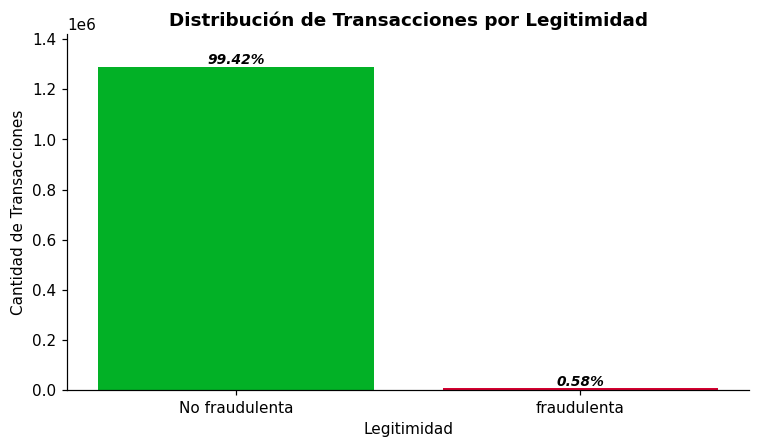

In [10]:
# Mostrando el conteo y el porcentaje de transacciones fraudulentas y no fraudukentas
conteo = df["is_fraud"].value_counts().sort_values(ascending=False)
total_legitimas = conteo[0]
porcentaje_no_fraudulentas = total_legitimas / len(df) * 100
total_fraudes = conteo[1]
porcentaje_fraudulentas = total_fraudes / len(df) * 100
print(f"Cantidad de transacciones no fraudulentas   : {total_legitimas:,.0f} \n"
      f"Porcentaje de transacciones no fraudulentas : {porcentaje_no_fraudulentas:.2f}%\n"
      f"Cantidad de transacciones fraudulentas      : {total_fraudes:,.0f} \n"
      f"Porcentaje de transacciones fraudulentas    : {porcentaje_fraudulentas:.2f}%")

# Mostrando la distribución de la variable "is_fraud" mediante conteo por categoría
plt.bar(["No fraudulenta", "fraudulenta"], conteo.values, color=[VERDE, ROJO])
plt.title("Distribución de Transacciones por Legitimidad")
plt.xlabel("Legitimidad")
plt.ylabel("Cantidad de Transacciones")
for posicion_x, valor in enumerate(conteo.values):
    if posicion_x == 0:
        porcentaje = porcentaje_no_fraudulentas
    else:
        porcentaje = porcentaje_fraudulentas
    plt.text(posicion_x, valor + 0.02, f"{porcentaje:.2f}%", ha="center", va="bottom",
             color="black", fontweight="bold", style="italic", fontsize=9)
plt.ylim(0, conteo.max() * 1.10)
plt.show()

## ***5. -*** *Análisis de Posibles Variables Predictoras*

### **5.1. -** Relación Legitimidad de Transacciones respecto a Hora de la Transacción

In [11]:
# Convirtiendo la fecha de la transacción de formato string a formato datetime
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["Hora"] = df["trans_date_trans_time"].dt.hour
df["Dia"] = df["trans_date_trans_time"].dt.day_name()
df["Nes"] = df["trans_date_trans_time"].dt.month

# Agrupando transacciones en torno a la hora de ejecución de la transacción
fraude_hora = df.groupby("Hora")["is_fraud"].agg(["count", "sum", "mean"])
fraude_hora.columns = ["Transacciones", "Fraudes", "Tasa de fraudes"]
fraude_hora["% tasa de fraudes"] = fraude_hora["Tasa de fraudes"] * 100
fraude_hora["% sobre total fraudes"] = fraude_hora["Fraudes"] / total_fraudes * 100

# Mostrando tabla resumen de legitimidad de transacciones según la hora de ejecución de la transacción
fraude_hora[["Transacciones", "Fraudes", "Tasa de fraudes", "% tasa de fraudes", "% sobre total fraudes"]]

,Transacciones,Fraudes,Tasa de fraudes,% tasa de fraudes,% sobre total fraudes
Hora,,,,,
0,42502,635,0.014940,1.494047,8.459899
1,42869,658,0.015349,1.534909,8.766320
2,42656,625,0.014652,1.465210,8.326672
3,42769,609,0.014239,1.423929,8.113509
4,41863,46,0.001099,0.109882,0.612843
5,42171,60,0.001423,0.142278,0.799361
6,42300,40,0.000946,0.094563,0.532907
7,42203,56,0.001327,0.132692,0.746070
8,42505,49,0.001153,0.115281,0.652811


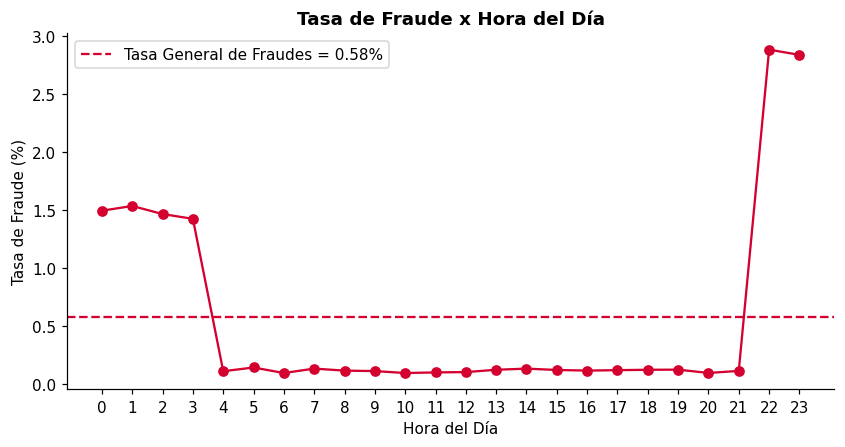

In [12]:
# Mostrando una gráfica sobre la tasa de fraude según la hora de ejecución de la transacción
plt.figure(figsize=(9, 4.2))
plt.plot(fraude_hora.index, fraude_hora["% tasa de fraudes"], marker="o", color=ROJO)
plt.title("Tasa de Fraude x Hora del Día")
plt.xlabel("Hora del Día")
plt.ylabel("Tasa de Fraude (%)")
plt.axhline(porcentaje_fraudulentas, color=ROJO, linestyle="--", label=f"Tasa General de Fraudes = {porcentaje_fraudulentas:.2f}%")
plt.xticks(range(24))
plt.legend()
plt.show()

### **5.2. -** Relación de legitimidad de Transacciones respecto del Canal de Transacción

Se establece la variable derivada `trans_channel`, que se deriva de la variable `category`. Revisando y agrupando los distintos tipos de negocio alojados en `category`, se obtienen tres posibles categorías de canal:

*   **En línea**
*   **Punto de Venta**
*   **Otros**

In [13]:
# Asignando un canal o medio de transacción a cada categoría de comercio
def obtener_canal(categoria):
    if categoria.endswith("_net"):
        return "En línea"
    elif categoria.endswith("_pos"):
        return "Punto de Venta"
    else:
        return "Otro"

df["transaction_channel"] = df["category"].apply(obtener_canal)

# Agrupando transacciones en torno al canal o medio de la transacción
fraude_canal = df.groupby("transaction_channel")["is_fraud"].agg(["count", "sum", "mean"])
fraude_canal.columns = ["Transacciones", "Fraudes", "Tasa de fraudes"]
fraude_canal = fraude_canal.rename_axis("Canal")
fraude_canal["% tasa de fraudes"] = fraude_canal["Tasa de fraudes"] * 100
fraude_canal["% sobre total de fraudes"] = fraude_canal["Fraudes"] / total_fraudes * 100

# Mostrando tabla resumen de legitimidad de transacciones según el canal o medio de la transacción
fraude_canal.sort_values("% sobre total de fraudes", ascending=False)

,Transacciones,Fraudes,Tasa de fraudes,% tasa de fraudes,% sobre total de fraudes
Canal,,,,,
Punto de Venta,319965,2836,0.008863,0.886347,37.783107
En línea,206282,2762,0.013389,1.338944,36.797229
Otro,770428,1908,0.002477,0.247655,25.419664


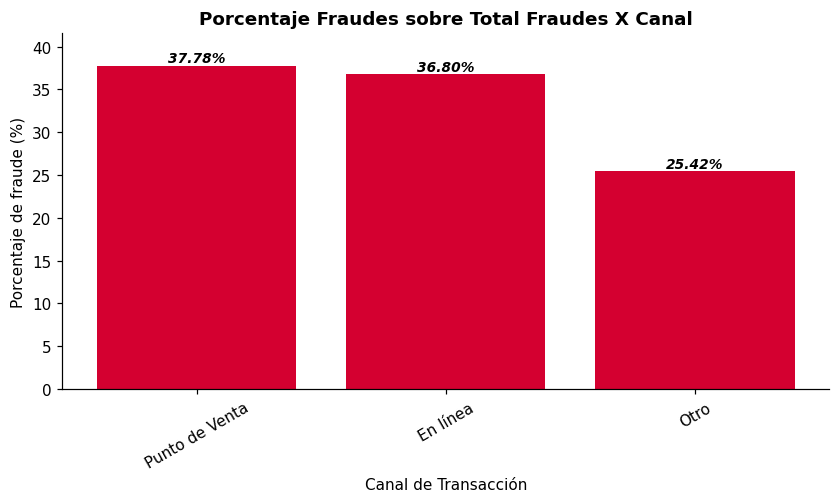

In [14]:
# Mostrando una gráfica sobre la tasa de fraude según el canal o medio de la transacción
fraude_canal = fraude_canal.sort_values("% sobre total de fraudes", ascending=False)

plt.figure(figsize=(9, 4.2))
plt.bar(fraude_canal.index, fraude_canal["% sobre total de fraudes"], color=ROJO)
plt.title("Porcentaje Fraudes sobre Total Fraudes X Canal")
plt.xlabel("Canal de Transacción")
plt.ylabel("Porcentaje de fraude (%)")
plt.xticks(range(3), rotation=30)
for posicion_x, valor in enumerate(fraude_canal["% sobre total de fraudes"].values):
    plt.text(posicion_x, valor + 0.02, f"{valor:.2f}%", ha="center", va="bottom",
             color="black", fontweight="bold", style="italic", fontsize=9)
plt.ylim(0, fraude_canal["% sobre total de fraudes"].max() * 1.10)
plt.show()

### **5.3. -** Relación de Legitimidad de Transacciones respecto del Monto de *Transacción*

In [15]:
# Agrupando los montos de transacción individuales en cuartiles con cantidades similares de observaciones
df["Monto de transacción"] = pd.qcut(df["amt"], q=4,
    labels=[
        "Monto bajo",
        "Monto medio - bajo",
        "Monto medio - alto",
        "Monto alto"
    ], duplicates="drop"
)

# Agrupando transacciones en torno al nivel de monto de la transacción
fraude_monto = df.groupby("Monto de transacción", observed=False)["is_fraud"].agg(["count", "sum", "mean"])
fraude_monto.columns = ["Transacciones", "Fraudes", "Tasa de fraudes"]
fraude_monto["% tasa de fraudes"] = fraude_monto["Tasa de fraudes"] * 100
fraude_monto["% sobre total de fraudes"] = fraude_monto["Fraudes"] / total_fraudes * 100

# Mostrando tabla resumen de legitimidad de transacciones según el nivel de monto de la transacción
fraude_monto.sort_values("% sobre total de fraudes", ascending=False)

,Transacciones,Fraudes,Tasa de fraudes,% tasa de fraudes,% sobre total de fraudes
Monto de transacción,,,,,
Monto alto,324112,5860,0.018080,1.808017,78.070877
Monto medio - bajo,324087,1104,0.003406,0.340649,14.708233
Monto bajo,324325,461,0.001421,0.142141,6.141753
Monto medio - alto,324151,81,0.000250,0.024988,1.079137


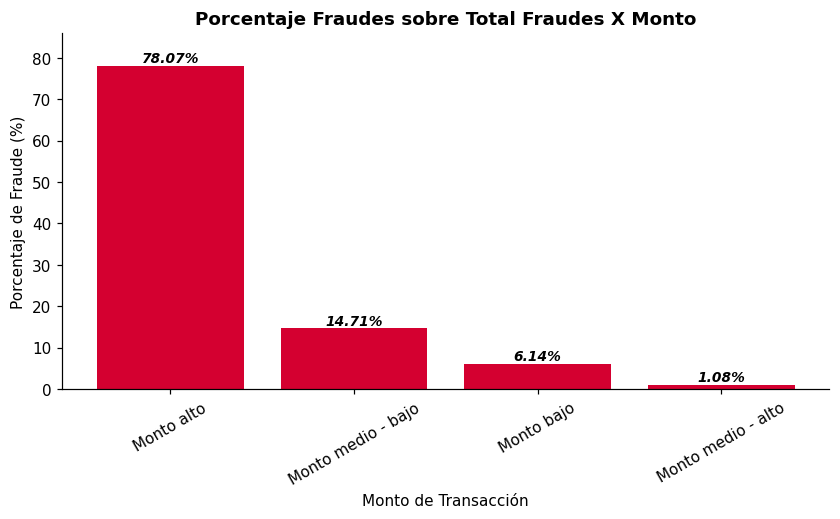

In [16]:
# Mostrando una gráfica sobre la tasa de fraude según el monto de la transacción
fraude_monto = fraude_monto.sort_values("% sobre total de fraudes", ascending=False)
plt.figure(figsize=(9, 4.2))
plt.bar(fraude_monto.index, fraude_monto["% sobre total de fraudes"], color=ROJO)
plt.title("Porcentaje Fraudes sobre Total Fraudes X Monto")
plt.xlabel("Monto de Transacción")
plt.ylabel("Porcentaje de Fraude (%)")
plt.xticks(range(4), rotation=30)
for posicion_x, valor in enumerate(fraude_monto["% sobre total de fraudes"].values):
    plt.text(posicion_x, valor + 0.02, f"{valor:.2f}%", ha="center", va="bottom",
             color="black", fontweight="bold", style="italic", fontsize=9)
plt.ylim(0, fraude_monto["% sobre total de fraudes"].max() * 1.10)
plt.show()

### **5.4. -** Relación de Legitimidad de Transacciones respecto de la Categoría de **Comercio**

In [17]:
# Agrupando transacciones en torno al tipo de comercio donde se efectúa de la transacción
fraude_categoria = df.groupby("category")["is_fraud"].agg(["count", "sum", "mean"])
fraude_categoria.columns = ["Transacciones", "Fraudes", "Tasa de fraudes"]
fraude_categoria = fraude_categoria.rename_axis("Categoría")
fraude_categoria["% tasa de fraudes"] = fraude_categoria["Tasa de fraudes"] * 100
fraude_categoria["% sobre total de fraudes"] = fraude_categoria["Fraudes"] / total_fraudes * 100

# Mostrando tabla resumen de legitimidad de transacciones según el tipo de comercio donde se efectúa de la transacción
fraude_categoria.sort_values("% sobre total de fraudes", ascending=False)

,Transacciones,Fraudes,Tasa de fraudes,% tasa de fraudes,% sobre total de fraudes
Categoría,,,,,
grocery_pos,123638,1743,0.014098,1.409761,23.221423
shopping_net,97543,1713,0.017561,1.756149,22.821743
misc_net,63287,915,0.014458,1.445795,12.190248
shopping_pos,116672,843,0.007225,0.722538,11.231015
gas_transport,131659,618,0.004694,0.469394,8.233413
misc_pos,79655,250,0.003139,0.313853,3.330669
kids_pets,113035,239,0.002114,0.211439,3.184119
entertainment,94014,233,0.002478,0.247835,3.104183
personal_care,90758,220,0.002424,0.242403,2.930989


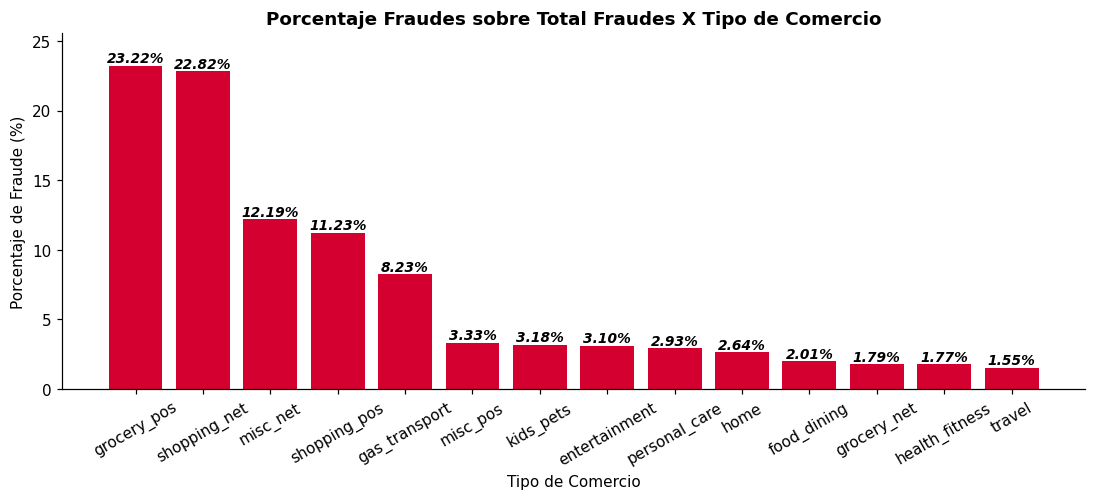

In [18]:
# Mostrando una gráfica sobre la tasa de fraude según el tipo de comercio donde se efectúa de la transacción
fraude_categoria = fraude_categoria.sort_values("% sobre total de fraudes", ascending=False)

plt.figure(figsize=(12, 4.2))
plt.bar(fraude_categoria.index, fraude_categoria["% sobre total de fraudes"], color=ROJO)
plt.title("Porcentaje Fraudes sobre Total Fraudes X Tipo de Comercio")
plt.xlabel("Tipo de Comercio")
plt.ylabel("Porcentaje de Fraude (%)")
plt.xticks(range(14), rotation=30)
for posicion_x, valor in enumerate(fraude_categoria["% sobre total de fraudes"].values):
    plt.text(posicion_x, valor + 0.02, f"{valor:.2f}%", ha="center", va="bottom",
             color="black", fontweight="bold", style="italic", fontsize=9)
plt.ylim(0, fraude_categoria["% sobre total de fraudes"].max() * 1.10)
plt.show()

### **5.5. -** Relación de Legitimidad de Transacciones respecto de la Razón entre Monto de Transacción y Promedio de una Tarjeta

Se establece la variable derivada `amt_vs_customer_avg`, que se deriva de la variable `amt`, que se obtiene a partir del monto de una transacción particular entre el promedio de los montos de transacción de una tarjeta específica.

In [19]:
# Obteniendo el promedio de montos por tarjeta de crédito
promedio_tarjeta = df.groupby("cc_num")["amt"].transform("mean")

# Obteniendo la razón entre monto de transacción y promedio de montos por tarjeta de crédito
df["amt_vs_customer_avg"] = df["amt"] / promedio_tarjeta

# Agrupando la legitimidad de las transacciones en torno a la razón entre monto de transacción y promedio de montos por tarjeta de crédito
fraude_prom_trans = df.groupby("is_fraud")["amt_vs_customer_avg"].agg(["count", "mean", "median", "min", "max"])
fraude_prom_trans.columns = ["Transacciones", "Media", "Mediana", "Mín", "Máx"]
fraude_prom_trans = fraude_prom_trans.rename_axis("Es fraude")

# Mostrando tabla resumen de la razón monto de transacción/promedio de montos según la legitimidad de la transacción
fraude_prom_trans.sort_values("Media", ascending=False)

,Transacciones,Media,Mediana,Mín,Máx
Es fraude,,,,,
1,7506,6.912082,5.184560,0.008693,23.912014
0,1289169,0.965578,0.666258,0.008779,386.481588


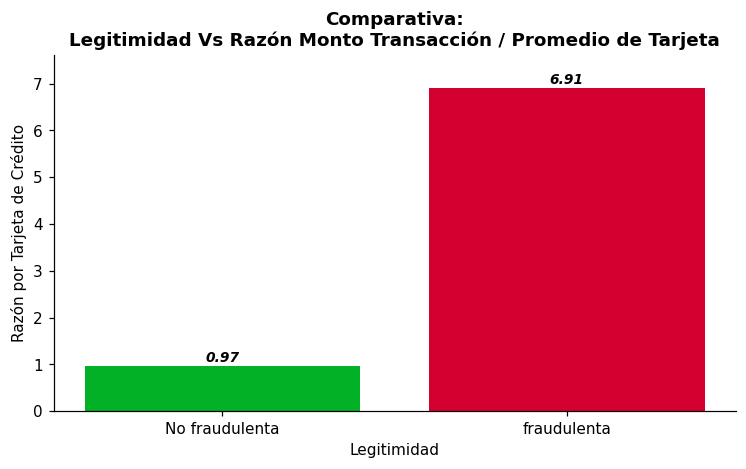

In [20]:
# Mostrando una gráfica sobre la comparativa del monto de las transacciones vs el promedio de montos para una tarjeta de crédito
plt.bar(["No fraudulenta", "fraudulenta"], fraude_prom_trans["Media"], color=[VERDE, ROJO])
plt.title("Comparativa:\nLegitimidad Vs Razón Monto Transacción / Promedio de Tarjeta")
plt.xlabel("Legitimidad")
plt.ylabel("Razón por Tarjeta de Crédito")
for posicion_x, valor in enumerate(fraude_prom_trans["Media"].values):
    plt.text(posicion_x, valor + 0.02, f"{valor:.2f}", ha="center", va="bottom",
             color="black", fontweight="bold", style="italic", fontsize=9)
plt.ylim(0, fraude_prom_trans["Media"].max() * 1.10)
plt.show()

# ***PARTE II - MODELADO PREDICTIVO***

En esta parte se utilizan los dos archivos que trae el dataset:

- `fraudTrain.csv`: Se usa para entrenar y comparar los modelos. Datos almacenados en la variable `df`. Utilizado en el análisis exploratorio de la PARTE I.
- `fraudTest.csv`: Se reserva para una prueba final del árbol ajustado. Datos almacenados en la variable `df_test`.

Dentro de `fraudTrain.csv` se hace una separación 80/20 con `random_state=42`, para hacer validación cruzada. La prueba final se realiza con `fraudTest.csv`.

---
---
## ***1. -*** *Preparación de Datos para Modelado*
---
---

### **1.1. -** Cargar el DataSet de Prueba


In [21]:
# Cargando el dataset que reservaremos para la prueba final
df_test = pd.read_csv("fraudTest.csv")

print("Datos para modelado:", df.shape)
print("Datos para prueba final:", df_test.shape)

Datos para modelado: (1296675, 28)
Datos para prueba final: (555719, 23)


### **1.2. -** Crear las Variables de Evaluación
---
Se utilizan las mismas variables estudiadas en el análisis exploratorio: La variable objetivo es `is_fraud`, mientras que las variables predictorias son:
- `Hora`: Hora en que ocurrió la transacción.
- `transaction_channel`: Canal de la transacción.
- `amt`: Monto de la transacción.
- `category`: Tipo de comercio.
- `amt_vs_customer_avg`: Tasa entre el monto y el promedio de la tarjeta

> `amt_vs_customer_avg` se calcula después de separar entrenamiento y validación, usando el promedio de cada tarjeta calculado solamente con los datos de entrenamiento.




In [22]:
# Obteniendo la variable "Hora" del DataSet de prueba
df_test["trans_date_trans_time"] = pd.to_datetime(df_test["trans_date_trans_time"])
df_test["Hora"] = df_test["trans_date_trans_time"].dt.hour

# Obteniendo la variable "Canal" del DataSet de prueba
df_test["transaction_channel"] = df_test["category"].apply(obtener_canal)

# Agrupando las variables predictoras a utilizar en el modelado
variables = ["amt", "Hora", "transaction_channel", "category"]

# Declarando conjunto de variables predictoras y variable objetivo del DataSet de entrenamiento
X = df[variables]
y = df["is_fraud"]

# Declarando conjunto de variables predictoras y variable objetivo del DataSet de prueba final
X_test_final = df_test[variables]
y_test_final = df_test["is_fraud"]

# Mostrando tablas con los valores de las variables predictorias de las primeras cinco y las últimas cinco transacciones
print("Primeras 5 filas:")
display(X.head())
print("\nUltimas 5 filas:")
display(X.tail())

Primeras 5 filas:


,amt,Hora,transaction_channel,category
0,4.97,0,En línea,misc_net
1,107.23,0,Punto de Venta,grocery_pos
2,220.11,0,Otro,entertainment
3,45.00,0,Otro,gas_transport
4,41.96,0,Punto de Venta,misc_pos



Ultimas 5 filas:


,amt,Hora,transaction_channel,category
1296670,15.56,12,Otro,entertainment
1296671,51.70,12,Otro,food_dining
1296672,105.93,12,Otro,food_dining
1296673,74.90,12,Otro,food_dining
1296674,4.30,12,Otro,food_dining


### **1.3. -** Convertir las Variables Categóricas a Números
---
Los modelos de `scikit-learn` necesitan trabajar con valores numéricos.  
Por eso convertimos `transaction_channel` y `category` en columnas de 0 y 1.

In [23]:
X = pd.get_dummies(
    X,
    columns=["transaction_channel", "category"],
    dtype=int
)

X_test_final = pd.get_dummies(
    X_test_final,
    columns=["transaction_channel", "category"],
    dtype=int
)

# Dejamos el dataset de prueba final con exactamente las mismas columnas de X
X_test_final = X_test_final.reindex(
    columns=X.columns,
    fill_value=0
)

print("Columnas de modelado:", X.shape[1])
print("Columnas de prueba final:", X_test_final.shape[1])

X.head()


Columnas de modelado: 19
Columnas de prueba final: 19


,amt,Hora,transaction_channel_En línea,transaction_channel_Otro,transaction_channel_Punto de Venta,category_entertainment,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
0,4.97,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,107.23,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,220.11,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,45.00,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
4,41.96,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0


### **1.4. -** Separación entre Datos de Entrenamiento y de Validación
---
Se utiliza el 80% de los daots en `fraudTrain.csv` para entrenamiento y el 20% para validación.

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Validación:", X_val.shape)

Entrenamiento: (1037340, 19)
Validación: (259335, 19)


### **1.5. -** Monto de la Transacción vs. Promedio de la Tarjeta
---
Esta variable compara cada monto con el comportamiento normal de esa tarjeta.

Ejemplo: si una tarjeta suele gastar alrededor de 50 y aparece una transacción de 250, la razón sería aproximadamente 5.

Para no utilizar información de validación antes de tiempo, el promedio por tarjeta se calcula únicamente con las filas de entrenamiento.

In [25]:
# Promedio de monto por tarjeta usando solamente el conjunto de entrenamiento
promedio_tarjeta_train = (
    df.loc[X_train.index]
      .groupby("cc_num")["amt"]
      .mean()
)

# Promedio general por si aparece una tarjeta que no esté en el entrenamiento
promedio_general_train = df.loc[X_train.index, "amt"].mean()

# Promedio correspondiente a cada tarjeta del entrenamiento
promedio_train = (
    df.loc[X_train.index, "cc_num"]
      .map(promedio_tarjeta_train)
      .fillna(promedio_general_train)
)

# Promedio correspondiente a cada tarjeta de validación
promedio_val = (
    df.loc[X_val.index, "cc_num"]
      .map(promedio_tarjeta_train)
      .fillna(promedio_general_train)
)

# Agregamos la nueva variable
X_train = X_train.copy()
X_val = X_val.copy()

X_train["amt_vs_customer_avg"] = (
    X_train["amt"] / promedio_train
)

X_val["amt_vs_customer_avg"] = (
    X_val["amt"] / promedio_val
)

X_train[["amt", "amt_vs_customer_avg"]].head()


,amt,amt_vs_customer_avg
330201,6.51,0.105677
798518,20.17,0.374052
1260375,35.85,0.393959
412511,42.21,0.654381
344644,57.24,0.624640


---
---
## ***2. -*** *Modelos Predictivos Aplicados*
---
---

### **2.1. -** Modelo Base (Baseline)
---

El baseline siempre predice la clase que aparece con mayor frecuencia.  
Por lo que no nos sirve como punto de comparación para saber si los otros modelos realmente están aprendiendo algo útil.

In [26]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_val)

pd.Series(y_pred_baseline).value_counts()

,count
0,259335


### **2.2. -** Árbol de Decisión
---

Prueba de arbol de Decisión

In [27]:
from sklearn.tree import DecisionTreeClassifier

modelo_arbol = DecisionTreeClassifier(random_state=42)
modelo_arbol.fit(X_train, y_train)
y_pred_arbol = modelo_arbol.predict(X_val)

pd.Series(y_pred_arbol).value_counts()

,count
0,257796
1,1539


### 4. Métricas y diagnóstico
---
Como el problema es de clasificación, se utilizarán:

- **Accuracy**: porcentaje total de predicciones correctas.
- **Precision**: de todo lo marcado como fraude, cuánto realmente era fraude.
- **Recall**: de todos los fraudes reales, cuántos detectó el modelo.
- **F1**: combina Precision y Recall.
- **Matriz de confusión**: muestra aciertos y errores de cada clase.

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Baseline
accuracy_baseline = accuracy_score(y_val, y_pred_baseline)
precision_baseline = precision_score(y_val, y_pred_baseline, zero_division=0)
recall_baseline = recall_score(y_val, y_pred_baseline, zero_division=0)
f1_baseline = f1_score(y_val, y_pred_baseline, zero_division=0)

# Árbol de decisión
accuracy_arbol = accuracy_score(y_val, y_pred_arbol)
precision_arbol = precision_score(y_val, y_pred_arbol)
recall_arbol = recall_score(y_val, y_pred_arbol)
f1_arbol = f1_score(y_val, y_pred_arbol)

### 4.1 Tabla comparativa
---
Esta tabla comparativa entre el baselina y el arbol de decisión

In [29]:
resultados = pd.DataFrame({
    "Modelo": ["Baseline", "Árbol de Decisión"],
    "Accuracy": [accuracy_baseline, accuracy_arbol],
    "Precision": [precision_baseline, precision_arbol],
    "Recall": [recall_baseline, recall_arbol],
    "F1": [f1_baseline, f1_arbol]})

resultados.round(4)

,Modelo,Accuracy,Precision,Recall,F1
0,Baseline,0.9941,0.0000,0.0000,0.000
1,Árbol de Decisión,0.9972,0.7563,0.7658,0.761


### 4.2 Matriz de confusión del árbol

In [30]:
confusion_matrix(y_val, y_pred_arbol)

array([[257440,    375],
       [   356,   1164]])

#### El modelo de confusión indica que el modelo clasifico 373 transacciones como fraudulentas pero eran legitimas, y 433 transacciones que eran fraudulentas como legitimas

### 5. Revisión de sobreajuste del árbol
---
Comparamos el rendimiento del árbol en los datos con los que aprendió y en los datos de validación.

In [31]:
# Predicciones del árbol sobre entrenamiento
y_pred_arbol_train = modelo_arbol.predict(X_train)

# Árbol de decisión con el de entrenamiento
accuracy_arbol_train = accuracy_score(y_train, y_pred_arbol_train)
precision_arbol_train = precision_score(y_train, y_pred_arbol_train)
recall_arbol_train = recall_score(y_train, y_pred_arbol_train)
f1_arbol_train = f1_score(y_train, y_pred_arbol_train)

comparacion_arbol = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Validación"],
    "Accuracy": [accuracy_arbol_train, accuracy_arbol],
    "Precision": [precision_arbol_train, precision_arbol],
    "Recall": [recall_arbol_train, recall_arbol],
    "F1": [f1_arbol_train, f1_arbol]})

comparacion_arbol.round(4)

,Conjunto,Accuracy,Precision,Recall,F1
0,Entrenamiento,1.0000,1.0000,1.0000,1.000
1,Validación,0.9972,0.7563,0.7658,0.761


Si las métricas de entrenamiento son mucho mejores que las de validación, puede existir sobreajuste.  
Para reducirlo probaremos diferentes valores de `max_depth`.

### 6. Validación cruzada y ajuste de profundidad

In [32]:
from sklearn.model_selection import cross_val_score

profundidades = [3, 5, 7, 10, 11, 13, 15, 20]

for profundidad in profundidades:

    arbol_prueba = DecisionTreeClassifier(
        max_depth=profundidad,
        random_state=42
    )

    resultados_cv = cross_val_score(
        arbol_prueba,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    )

    print(
        "Profundidad:", profundidad,
        "- F1 promedio:", resultados_cv.mean()
    )

Profundidad: 3 - F1 promedio: 0.6695924428144199
Profundidad: 5 - F1 promedio: 0.7027827141681545
Profundidad: 7 - F1 promedio: 0.785229307511816
Profundidad: 10 - F1 promedio: 0.8079999334957982
Profundidad: 11 - F1 promedio: 0.8086539653685667
Profundidad: 13 - F1 promedio: 0.8039558391103604
Profundidad: 15 - F1 promedio: 0.7977151042385253
Profundidad: 20 - F1 promedio: 0.7757009012535282


En las pruebas realizadas anteriormente, `max_depth=11` presentó el mejor F1 promedio entre los valores evaluados.  
Por eso se utilizará esa profundidad para el árbol ajustado.

### 6.1 Árbol ajustado

In [33]:
modelo_arbol_ajustado = DecisionTreeClassifier(max_depth=11, random_state=42)

modelo_arbol_ajustado.fit(X_train, y_train)

y_pred_arbol_ajustado = modelo_arbol_ajustado.predict(X_val)

In [34]:
accuracy_arbol_ajustado = accuracy_score(y_val, y_pred_arbol_ajustado)
precision_arbol_ajustado = precision_score(y_val, y_pred_arbol_ajustado)
recall_arbol_ajustado = recall_score(y_val, y_pred_arbol_ajustado)
f1_arbol_ajustado = f1_score(y_val, y_pred_arbol_ajustado)

print("Accuracy:", accuracy_arbol_ajustado)
print("Precision:", precision_arbol_ajustado)
print("Recall:", recall_arbol_ajustado)
print("F1:", f1_arbol_ajustado)

Accuracy: 0.9980180075963522
Precision: 0.8748137108792846
Recall: 0.7723684210526316
F1: 0.8204053109713487


In [35]:
confusion_matrix(y_val, y_pred_arbol_ajustado)

array([[257647,    168],
       [   346,   1174]])

### Comparación el de entrenamiento vs el de validación

In [36]:
# Predicciones del árbol sobre entrenamiento
y_pred_arbol_train = modelo_arbol_ajustado.predict(X_train)

# Árbol de decisión con el de entrenamiento
accuracy_arbol_train = accuracy_score(y_train, y_pred_arbol_train)
precision_arbol_train = precision_score(y_train, y_pred_arbol_train)
recall_arbol_train = recall_score(y_train, y_pred_arbol_train)
f1_arbol_train = f1_score(y_train, y_pred_arbol_train)

comparacion_arbol = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Validación"],
    "Accuracy": [accuracy_arbol_train, accuracy_arbol_ajustado],
    "Precision": [precision_arbol_train, precision_arbol_ajustado],
    "Recall": [recall_arbol_train, recall_arbol_ajustado],
    "F1": [f1_arbol_train, f1_arbol_ajustado]})

comparacion_arbol.round(4)

,Conjunto,Accuracy,Precision,Recall,F1
0,Entrenamiento,0.9985,0.9323,0.8002,0.8612
1,Validación,0.9980,0.8748,0.7724,0.8204


### 6.2 Comparación final de modelos

In [37]:
resultados_finales = pd.DataFrame({
    "Modelo": ["Baseline", "Árbol de Decisión Ajustado"],
    "Accuracy": [accuracy_baseline, accuracy_arbol_ajustado],
    "Precision": [precision_baseline, precision_arbol_ajustado],
    "Recall": [recall_baseline, recall_arbol_ajustado],
    "F1": [f1_baseline, f1_arbol_ajustado]})

resultados_finales.round(4)

,Modelo,Accuracy,Precision,Recall,F1
0,Baseline,0.9941,0.0000,0.0000,0.0000
1,Árbol de Decisión Ajustado,0.9980,0.8748,0.7724,0.8204


### 7. Prueba final con `df_test`
---
Dado que ya se entrenó con parte del dataset de train, podemos entrenarlo con todo las transacciones de prueba y probarlo con el test.

In [38]:
# Para el modelo final usamos fraudTrain
#  calcular el promedio por tarjeta usando df.
promedio_tarjeta_final = df.groupby("cc_num")["amt"].mean()
promedio_general_final = df["amt"].mean()

# Copias para no alterar las variables anteriores
X_final = X.copy()
X_test_final = X_test_final.copy()

# Nueva variable para el dataset de entrenamiento
promedio_final_train = (
    df["cc_num"]
      .map(promedio_tarjeta_final)
      .fillna(promedio_general_final)
)

X_final["amt_vs_customer_avg"] = (
    X_final["amt"] / promedio_final_train
)

# Para fraudTest.csv usamos los promedios aprendidos de fraudTrain.csv
promedio_final_test = (
    df_test["cc_num"]
      .map(promedio_tarjeta_final)
      .fillna(promedio_general_final)
)

X_test_final["amt_vs_customer_avg"] = (X_test_final["amt"] / promedio_final_test)

# Entrenamos el árbol final con fraudTrain.csv
modelo_arbol_final = DecisionTreeClassifier(max_depth=11, random_state=42)

modelo_arbol_final.fit(X_final, y)

# Predicción sobre fraudTest.csv
y_pred_final = modelo_arbol_final.predict(X_test_final)

In [39]:
accuracy_final = accuracy_score(y_test_final, y_pred_final)
precision_final = precision_score(y_test_final, y_pred_final)
recall_final = recall_score(y_test_final, y_pred_final)
f1_final = f1_score(y_test_final, y_pred_final)

print("Accuracy prueba final:", accuracy_final)
print("Precision prueba final:", precision_final)
print("Recall prueba final:", recall_final)
print("F1 prueba final:", f1_final)

Accuracy prueba final: 0.9983228934047603
Precision prueba final: 0.8390162101732812
Recall prueba final: 0.6997668997668998
F1 prueba final: 0.7630910015251652


In [40]:
confusion_matrix(y_test_final, y_pred_final)

array([[553286,    288],
       [   644,   1501]])

### Validación de resultados, del entrenamiento, la validación y el test final

In [41]:
comparacion_arbol = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Validación", "Prueba FraudTest.csv"],
    "Accuracy": [accuracy_arbol_train, accuracy_arbol_ajustado, accuracy_final],
    "Precision": [precision_arbol_train, precision_arbol_ajustado, precision_final],
    "Recall": [recall_arbol_train, recall_arbol_ajustado, recall_final],
    "F1": [f1_arbol_train, f1_arbol_ajustado, f1_final]})

comparacion_arbol.round(4)

,Conjunto,Accuracy,Precision,Recall,F1
0,Entrenamiento,0.9985,0.9323,0.8002,0.8612
1,Validación,0.9980,0.8748,0.7724,0.8204
2,Prueba FraudTest.csv,0.9983,0.8390,0.6998,0.7631


In [42]:
resultados_finales = pd.DataFrame({
    "Modelo": ["Baseline", "Árbol de Decisión Test.csv"],
    "Accuracy": [accuracy_baseline, accuracy_final],
    "Precision": [precision_baseline, precision_final],
    "Recall": [recall_baseline, recall_final],
    "F1": [f1_baseline, f1_final]})

resultados_finales.round(4)

,Modelo,Accuracy,Precision,Recall,F1
0,Baseline,0.9941,0.000,0.0000,0.0000
1,Árbol de Decisión Test.csv,0.9983,0.839,0.6998,0.7631


### 8. Importancia de variables
---
Variables que el árbol utilizó con mayor importancia para tomar sus decisiones.

In [43]:
importancia_variables = pd.DataFrame({
    "Variable": X_final.columns,
    "Importancia": modelo_arbol_final.feature_importances_
})

importancia_variables = importancia_variables.sort_values(
    "Importancia",
    ascending=False
)

importancia_variables.head(10)

,Variable,Importancia
0,amt,0.344507
9,category_grocery_pos,0.259051
1,Hora,0.170648
7,category_gas_transport,0.094365
19,amt_vs_customer_avg,0.078004
16,category_shopping_net,0.011233
14,category_misc_pos,0.008707
2,transaction_channel_En línea,0.007023
11,category_home,0.006848
13,category_misc_net,0.005243


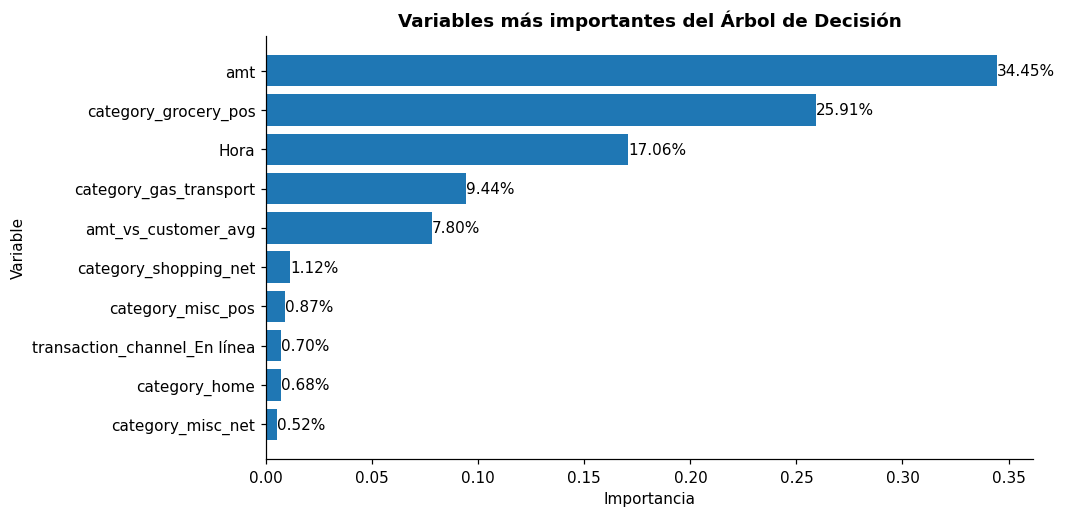

In [44]:
top_variables = importancia_variables.head(10)

plt.figure(figsize=(9, 5))

barras = plt.barh(
    top_variables["Variable"][::-1],
    top_variables["Importancia"][::-1]
)
plt.title("Variables más importantes del Árbol de Decisión")
plt.xlabel("Importancia")
plt.ylabel("Variable")

#agregar porcentaje de importancia
for barra in barras:
    valor = barra.get_width()

    plt.text(
        valor,
        barra.get_y() + barra.get_height() / 2,
        f"{valor * 100:.2f}%",
        va = "center"
    )

plt.show()

---
### **2.3. -** Modelo 2 Random Forest
---

#### 2.3.1. - Librerias


In [45]:
# Importamos RandomForestClassifier como algoritmo central de ensamble por bagging
from sklearn.ensemble import RandomForestClassifier
# Importamos seaborn para gráficos estadísticos avanzados
import seaborn as sns
# Importamos la librería SHAP para análisis de explicabilidad local y global
import shap
# Importamos función para generar el reporte completo con precisión, recall y F1 por clase
from sklearn.metrics import classification_report
# Importamos función para calcular la matriz de confusión cuantitativa
from sklearn.metrics import confusion_matrix
# Importamos clase para graficar visualmente la matriz de confusión
from sklearn.metrics import ConfusionMatrixDisplay

In [46]:
# Ajustamos los parámetros globales de estilo para los gráficos de matplotlib
plt.rcParams.update({"figure.figsize": (8, 4.2), "axes.titleweight": "bold"})

#### 2.3.1. - Implementacion del Modelo Random Forest

In [47]:
# Instanciando el ensamble Random Forest con los hiperparámetros
modelo_rf = RandomForestClassifier(
    n_estimators=300,    # Número de árboles en el bosque (300 ofrece estabilidad sin sobreajustar)
    max_samples=0.5,     # 50% de los datos de entrenamiento
    max_features="sqrt", # Cantidad de variables elegidas al azar en cada corte (raíz cuadrada del total)
    max_depth=18,        # profundidad establecida para evitar que memorice datos inecesarios para el uso de DataSet de pruebas
    min_samples_leaf=2,  # hojas grupo
    random_state=42,     # Semilla aleatoria para garantizar la reproducibilidad de los resultados
    n_jobs=-1,           # Uso de todos los núcleos del procesador en paralelo para acelerar el cálculo
)

# Entrenamos el modelo de bosque de árboles aleatorios con el conjunto de datos de entrenamiento
modelo_rf.fit(X_train, y_train)

# Generando las predicciones del Random Forest sobre el conjunto de datos de validación
y_pred_rf = modelo_rf.predict(X_val)

# Calculando las métricas para Random Forest (umbral por defecto: 0.5)
accuracy_rf = accuracy_score(y_val, y_pred_rf)                    # Exactitud global
precision_rf = precision_score(y_val, y_pred_rf, zero_division=0) # Precisión de detección
recall_rf = recall_score(y_val, y_pred_rf, zero_division=0)       # Sensibilidad (Recall)
f1_rf = f1_score(y_val, y_pred_rf, zero_division=0)               # Métrica combinada (F1 Score)

# Contamos y mostramos cuántas predicciones son No Fraudes (0) y cuántos son Fraudes (1)
print(pd.Series(y_pred_rf).value_counts().rename({0: "No Fraudes", 1: "Fraudes"}))
# Imprimimos el resumen numérico de métricas del algoritmo Random Forest
print(
    f"\n=== RANDOM FOREST 300 ===\nExactitud: {accuracy_rf:.4f} | Precisión:"
    f" {precision_rf:.4f} | Recall: {recall_rf:.4f} | F1: {f1_rf:.4f}")

No Fraudes    258089
Fraudes         1246
Name: count, dtype: int64

=== RANDOM FOREST 300 ===
Exactitud: 0.9982 | Precisión: 0.9189 | Recall: 0.7533 | F1: 0.8279


#### 2.3.2. - Buscando el Mejor Umbral (Validación)

In [48]:
# Generamos las predicciones del Random Forest sobre el conjunto de validación
y_pred_rf_2 = modelo_rf.predict_proba(X_val)

y_pred_rf_pos = y_pred_rf_2[:, 1] # Predicciones de fraude

# Evaluando umbrales de decisión
print("\nEvaluando umbrales para mejorar el F1-Score:\n")
lista_umbrales = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]
f1_rf_mejor_umbral = f1_score(y_val, (y_pred_rf_pos >= 0.5).astype(int), zero_division=0)
rf_mejor_umbral = 0.5
lista_acc_rf_umbral, lista_prec_rf_umbral, lista_rec_rf_umbral, lista_f1_rf_umbral = [], [], [], []
for umbral in lista_umbrales:
  y_pred_rf_ajustada = (y_pred_rf_pos >= umbral).astype(int)

  # Calculando las métricas con este umbral específico
  accuracy_rf_umbral = accuracy_score(y_val, y_pred_rf_ajustada)
  lista_acc_rf_umbral.append(accuracy_rf_umbral)
  precision_rf_umbral = precision_score(y_val, y_pred_rf_ajustada, average='binary', zero_division=0)
  lista_prec_rf_umbral.append(precision_rf_umbral)
  recall_rf_umbral = recall_score(y_val, y_pred_rf_ajustada, average='binary', zero_division=0)
  lista_rec_rf_umbral.append(recall_rf_umbral)
  f1_rf_umbral = f1_score(y_val, y_pred_rf_ajustada, average='binary', zero_division=0)
  lista_f1_rf_umbral.append(f1_rf_umbral)
  if f1_rf_umbral > f1_rf_mejor_umbral:
    f1_rf_mejor_umbral = f1_rf_umbral
    rf_mejor_umbral = umbral

# Mostrando la tabla con las métricas obtenidas para cada umbral
tabla_umbrales = pd.DataFrame({
    "Threshold" : lista_umbrales,
    "Accuracy"  : lista_acc_rf_umbral,
    "Precision" : lista_prec_rf_umbral,
    "Recall"    : lista_rec_rf_umbral,
    "F1"        : lista_f1_rf_umbral})

display(tabla_umbrales.round(4))

# Mostrando el mejor umbral respecto al F1
print(f"\nMejor umbral para F1: {rf_mejor_umbral:.2f}\n"
      f"F1 en validación: {f1_rf_mejor_umbral:.4f}")


Evaluando umbrales para mejorar el F1-Score:



,Threshold,Accuracy,Precision,Recall,F1
0,0.20,0.9977,0.7799,0.8487,0.8129
1,0.25,0.9979,0.8141,0.8329,0.8234
2,0.30,0.9980,0.8393,0.8211,0.8301
3,0.35,0.9981,0.8692,0.8046,0.8357
4,0.40,0.9982,0.8925,0.7862,0.8360
5,0.45,0.9982,0.9032,0.7671,0.8296
6,0.50,0.9982,0.9189,0.7533,0.8279
7,0.55,0.9981,0.9309,0.7355,0.8218
8,0.60,0.9980,0.9406,0.7086,0.8083
9,0.65,0.9980,0.9572,0.6908,0.8024



Mejor umbral para F1: 0.40
F1 en validación: 0.8360


#### 2.3.3. - Tabla Comparativa

In [53]:
resultados_rf = pd.DataFrame({
    "Modelo": ["Baseline", "Random Forest [300 árboles - default]", f"Random Forest [300 árboles - Threshold: {rf_mejor_umbral}]"],
    "Accuracy": [accuracy_baseline, accuracy_rf, lista_acc_rf_umbral[4]],
    "Precision": [precision_baseline, precision_rf, lista_prec_rf_umbral[4]],
    "Recall": [recall_baseline, recall_rf, lista_rec_rf_umbral[4]],
    "F1": [f1_baseline, f1_rf, lista_f1_rf_umbral[4]]})

resultados_rf.round(4)

,Modelo,Accuracy,Precision,Recall,F1
0,Baseline,0.9941,0.0000,0.0000,0.0000
1,Random Forest [300 árboles - default],0.9982,0.9189,0.7533,0.8279
2,Random Forest [300 árboles - Threshold: 0.4],0.9982,0.8925,0.7862,0.8360


#### 2.3.4. - Matriz de Confusión

In [54]:
rf_mc_1 = confusion_matrix(y_val, y_pred_rf)

# La convertimos a DataFrame solo para ponerle nombres a filas y columnas
tabla_1 = pd.DataFrame(
    rf_mc_1,
    index=["Real: No fraudulenta", "Real: Fraudulenta"],
    columns=["Predijo: No fraudulenta", "Predijo: Fraudulenta"],
)

tabla_1

,Predijo: No fraudulenta,Predijo: Fraudulenta
Real: No fraudulenta,257714,101
Real: Fraudulenta,375,1145


#### 2.3.5. - Revisión de Sobreajuste

In [55]:
# Generando las predicciones del modelo Random Forest sobre el conjunto de datos de entrenamiento
y_pred_rf_train = modelo_rf.predict(X_train)

# Calculando valor de métricas del Random Forest con datos de entrenamiento
accuracy_rf_train = accuracy_score(y_train, y_pred_rf_train)
precision_rf_train = precision_score(y_train, y_pred_rf_train)
recall_rf_train = recall_score(y_train, y_pred_rf_train)
f1_rf_train = f1_score(y_train, y_pred_rf_train)

comparacion_rf = pd.DataFrame({
    "Conjunto": ["Random Forest (Entrenamiento)", "Random Forest (Validación)"],
    "Accuracy": [accuracy_rf_train, accuracy_rf],
    "Precision": [precision_rf_train, precision_rf],
    "Recall": [recall_rf_train, recall_rf],
    "F1": [f1_rf_train, f1_rf]})

comparacion_rf.round(4)

,Conjunto,Accuracy,Precision,Recall,F1
0,Random Forest (Entrenamiento),0.9986,0.9641,0.7845,0.8651
1,Random Forest (Validación),0.9982,0.9189,0.7533,0.8279


#### 2.3.6. - Validación Cruzada y Ajuste de Hiperparámetros

In [ ]:
from sklearn.model_selection import GridSearchCV

malla = {"max_depth" : [10, 12, 14], "min_samples_leaf" : [2, 4, 6]}

busqueda_rf = GridSearchCV(
    RandomForestClassifier(
        max_features="sqrt",
        oob_score=True,
        random_state=42,
        n_jobs=-1),
    param_grid=malla,
    cv=5,
    return_train_score=True,
    scoring="f1",
    n_jobs=1,
)
busqueda_rf.fit(X_train, y_train)

print("Mejor combinación:", busqueda_rf.best_params_)
print(f"F1 en validación cruzada: {busqueda_rf.best_score_:.3f}")

modelo_rf_ajustado = busqueda_rf.best_estimator_    # ya reentrenado con todo X_train

#### 2.3.7. - Modelo Ajustado

In [ ]:
# La tabla completa, ordenada de mejor a peor
resultados_rf = pd.DataFrame(busqueda_rf.cv_results_)
resultados_rf[["param_max_depth", "param_min_samples_leaf",
            "mean_test_score", "std_test_score"]].sort_values(
    "mean_test_score", ascending=False).round(3)

In [ ]:
# AHORA SÍ, y una sola vez: medimos en prueba
y_pred_rf_ajustado = modelo_rf_ajustado.predict_proba(X_val)
y_pred_rf_ajustado_pos = y_pred_rf_ajustado[:,1]

accuracy_rf_ajustado = accuracy_score(y_val, (y_pred_rf_ajustado >= 0.4).astype(int))
precision_rf_ajustado = precision_score(y_val, (y_pred_rf_ajustado >= 0.4).astype(int))
recall_rf_ajustado = recall_score(y_val, (y_pred_rf_ajustado >= 0.4).astype(int))
f1_rf_ajustado = f1_score(y_val, (y_pred_rf_ajustado >= 0.4).astype(int))

print("Accuracy en el modelo Random Forest ajustado:", accuracy_rf_ajustado)
print("Precision en el modelo Random Forest ajustado:", precision_rf_ajustado)
print("Recall en el modelo Random Forest ajustado:", recall_rf_ajustado)
print("F1 en el modelo Random Forest ajustado:", f1_rf_ajustado)

In [ ]:
confusion_matrix(y_val, (y_pred_rf_ajustado >= 0.4).astype(int))

#### 2.3.8. Comparación entre Entrenamiento y Validación

In [ ]:
# Predicciones del modelo Random Forest sobre entrenamiento
y_pred_rf_train_ajustado = modelo_rf_ajustado.predict_proba(X_train)
y_pred_rf_train_ajustado_pos = y_pred_rf_train_ajustado[:,1]

# Calculando las métricas del modelo Random Forest con los datos de entrenamiento
accuracy_rf_train_ajustado = accuracy_score(y_train, (y_pred_rf_train_ajustado_pos >= 0.4).astype(int))
precision_rf_train_ajustado = precision_score(y_train, (y_pred_rf_train_ajustado_pos >= 0.4).astype(int))
recall_rf_train_ajustado = recall_score(y_train, (y_pred_rf_train_ajustado_pos >= 0.4).astype(int))
f1_rf_train_ajustado = f1_score(y_train, (y_pred_rf_train_ajustado_pos >= 0.4).astype(int))

comparacion_rf_2 = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Validación"],
    "Accuracy": [accuracy_rf_train_ajustado, accuracy_rf_ajustado],
    "Precision": [precision_rf_train_ajustado, precision_rf_ajustado],
    "Recall": [recall_rf_train_ajustado, recall_rf_ajustado],
    "F1": [f1_rf_train_ajustado, f1_rf_ajustado]})

comparacion_rf_2.round(4)

#### 2.3.9. - Comparación Final de Modelos

In [ ]:
resultados_finales_rf = pd.DataFrame({
    "Modelo": ["Baseline", "Random Forest Ajustado"],
    "Accuracy": [accuracy_baseline, accuracy_rf_ajustado],
    "Precision": [precision_baseline, precision_rf_ajustado],
    "Recall": [recall_baseline, recall_rf_ajustado],
    "F1": [f1_baseline, f1_rf_ajustado]})

resultados_finales_rf.round(4)

#### 2.3.10. - Prueba Final con `df_test`

In [ ]:
# Entrenamos el árbol final con fraudTrain.csv
modelo_rf_final = RandomForestClassifier(
    n_estimators=300,
    max_samples=0.5,
    max_features="sqrt",
    max_depth=14,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

modelo_rf_final.fit(X_final, y)

# Predicción sobre fraudTest.csv
y_pred_final = modelo_rf_final.predict_proba(X_test_final)
y_pred_final_pos = y_pred_final[:,1]

In [ ]:
accuracy_rf_final = accuracy_score(y_test_final, (y_pred_final_pos >= 0.40).astype(int))
precision_rf_final = precision_score(y_test_final, (y_pred_final_pos >= 0.40).astype(int))
recall_rf_final = recall_score(y_test_final, (y_pred_final_pos >= 0.40).astype(int))
f1_rf_final = f1_score(y_test_final, (y_pred_final_pos >= 0.40).astype(int))

print("Accuracy prueba final:", accuracy_rf_final)
print("Precision prueba final:", precision_rf_final)
print("Recall prueba final:", recall_rf_final)
print("F1 prueba final:", f1_rf_final)

In [ ]:
confusion_matrix(y_test_final, (y_pred_final_pos >= 0.40).astype(int))

#### 2.3.11. - Validación de Resultados, del Entrenamiento, Validación y Test Final

In [ ]:
comparacion_rf_final = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Validación", "Prueba FraudTest.csv"],
    "Accuracy": [accuracy_rf_train, accuracy_rf_ajustado, accuracy_rf_final],
    "Precision": [precision_rf_train, precision_rf_ajustado, precision_rf_final],
    "Recall": [recall_rf_train, recall_rf_ajustado, recall_rf_final],
    "F1": [f1_rf_train, f1_rf_ajustado, f1_rf_final]})

comparacion_rf_final.round(4)

In [ ]:
resultados_finales_rf_2 = pd.DataFrame({
    "Modelo": ["Baseline", "Random Fores Test.csv"],
    "Accuracy": [accuracy_baseline, accuracy_rf_final],
    "Precision": [precision_baseline, precision_rf_final],
    "Recall": [recall_baseline, recall_rf_final],
    "F1": [f1_baseline, f1_rf_final]})

resultados_finales_rf_2.round(4)

#### 2.3.12. - Importancia de Variables y Explicabilidad SHAP

In [ ]:
# Calculamos la importancia global relativa de las variables a partir del objeto bosque entrenado
importancias = pd.Series(
    modelo_rf_final.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

# Inicializamos el gráfico horizontal para graficar el Top 10 de variables más importantes
plt.figure(figsize=(9, 4.5))

# Graficamos las 10 características con mayor ponderación en el modelo
top_10 = importancias.head(10)
ax = top_10.plot(kind="barh", color="#13294B")
ax.invert_yaxis()

# Anexamos el porcentaje al final de cada barra
for p in ax.patches:
  width = p.get_width()
  ax.text(
      width + (ax.get_xlim()[1] * 0.01),
      p.get_y() + p.get_height() / 2,
      f"{width * 100:.1f}%",
      va="center",
      ha="left",
      fontsize=9,
      color="black",
      weight="bold",
  )

# Ajustamos el límite del eje X para que los textos de los porcentajes no se corten
plt.xlim(0, top_10.max() * 1.18)

# Definimos el título del gráfico de importancia de variables
plt.title("Top 10 Importancia de Variables (Random Forest)")
# Etiquetamos el eje horizontal como Importancia Relativa
plt.xlabel("Importancia Relativa")
# Renderizamos el gráfico
plt.show()

# Instanciamos el explicador SHAP especializado para modelos basados en árboles (TreeExplainer)
explainer = shap.TreeExplainer(modelo_rf_final)
# Tomamos una muestra aleatoria de 500 instancias de test para optimizar la velocidad de cómputo SHAP
sample_X_test = X_test_final.sample(min(500, len(X_test_final)), random_state=42)
# Calculamos los valores SHAP para la muestra seleccionada
val_shap = explainer(sample_X_test)

# Graficamos el resumen SHAP caso por caso mostrando la contribución y dirección de cada variable
shap.summary_plot(val_shap[..., 1], sample_X_test)

#### 2.3.13. - Evaluación Gráfica y Diagnóstico

In [ ]:
# Imprimimos la matriz de confusión textual para el modelo Random Forest
print("Matriz de Confusión (Random Forest):")
# Calculamos y mostramos la matriz comparando y_test con y_pred_bosque
print(confusion_matrix(y_test_final, (y_pred_final_pos >= 0.40)))
# Imprimimos el reporte completo de clasificación detallando métricas por cada clase
print("\nReporte de Clasificación Completo:")
# Generamos el reporte especificando los nombres de las etiquetas ("Legítima" y "Fraude")
print(
    classification_report(
        y_test_final, (y_pred_final_pos >= 0.40), target_names=["Legítima", "Fraude"]
    )
)
# Creamos una figura y un eje de matplotlib para dibujar la gráfica de confusión
fig, ax = plt.subplots(figsize=(6, 5))
# Graficamos la matriz de confusión visual utilizando la herramienta ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    modelo_rf_final, X_test_final, y_test_final, display_labels=["Legítima", "Fraude"], ax=ax
)
# Asignamos un título descriptivo al gráfico de la matriz de confusión
plt.title("Matriz de Confusión - Random Forest")
# Desactivamos las líneas de cuadrícula internas para una presentación más limpia
plt.grid(False)
# Desplegamos la figura gráfica en pantalla
plt.show()

#  Tabla Comparativa de Resultados Finales

In [ ]:
# Construimos un DataFrame consolidado con los resultados de los modelos evaluados en prueba
tabla_comparativa_final = pd.DataFrame({
    'Modelo': ['Baseline', 'Árbol de Decisión Test.csv', 'Random Forest Test.csv'],
    'Exactitud': [accuracy_baseline,accuracy_final,accuracy_rf_final],
    'Precisión': [precision_baseline,precision_final,precision_rf_final],
    'Recall': [recall_baseline,recall_final,recall_rf_final],
    'F1-Score': [f1_baseline,f1_final,f1_rf_final],
})

# Imprimimos el encabezado explicativo de la tabla comparativa final
print("=== TABLA COMPARATIVA DE RESULTADOS (EVALUADOS EN FRAUDTEST.CSV) ===")
# Desplegamos la tabla comparativa con formato visual de DataFrame
display(tabla_comparativa_final)

# Creamos una figura para mostrar la gráfica de barras comparativa del F1-Score
plt.figure(figsize=(8, 4))
# Trazamos el gráfico de barras asignando colores distintos a cada modelo
bars = plt.bar(
    tabla_comparativa_final['Modelo'],
    tabla_comparativa_final['F1-Score'],
    color=['#5A6577', '#13294B', '#02B126', '#D40030'],
)
# Asignamos el título al gráfico comparativo
plt.title('Comparativa de F1-Score en Conjunto de Prueba')
# Etiquetamos el eje vertical con la métrica representada
plt.ylabel('F1 en fraudTest.csv')
# Fijamos el límite del eje Y entre 0 y 1.05
plt.ylim(0, 1.05)

# Iteramos sobre cada barra para imprimir el valor numérico exacto encima de ella
for bar in bars:
  # Obtenemos la altura (valor F1) de la barra actual
  y = bar.get_height()
  # Escribimos el valor formateado a tres decimales centrado en la parte superior de la barra
  plt.text(
      bar.get_x() + bar.get_width() / 2,
      y + 0.02,
      f'{y:.3f}',
      ha='center',
      fontweight='bold',
  )

# Ajustamos la distribución espacial del gráfico para evitar solapamientos
plt.tight_layout()
# Mostramos la gráfica final en pantalla
plt.show()

RANDOM FOREST 2

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    max_samples=0.95,
    max_depth=20,
    oob_score=True,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train) # Entrenamiento

y_pred_rf = rf.predict(X_val) # Prueba de validación

print(f"Random Forest:  F1 {f1_score(y_test, y_pred_rf):.3f}")
print(f"\nPuntaje out-of-bag (exactitud, sin usar prueba): {rf.oob_score_:.3f}")

In [ ]:
# Calculando valores de las métricas del modelo random forest
rf_acc_sc = accuracy_score(y_test, rf_y_pred)                    # Exactitud
rf_pres_sc = precision_score(y_test, rf_y_pred, zero_division=0) # Precisión
rf_rec_sc = recall_score(y_test, rf_y_pred, zero_division=0)     # Recall
rf_f1_sc = f1_score(y_test, rf_y_pred, zero_division=0)          # F1

# Mostrando tabla resumen con las métricas calculadas en el baseline y los modelos
res_scs_df = pd.DataFrame({
        "Exactitud" : [base_acc_sc, rf_acc_sc],
        "Precisión" : [base_pres_sc, rf_pres_sc],
        "Recall" : [base_rec_sc, rf_rec_sc],
        "F1" : [base_f1_sc, rf_f1_sc]}, index=["Baseline", "Random Forest (300 árboles)"])
res_scs_df = res_scs_df.rename_axis("MÉTRICAS")
res_scs_df.round(4)

In [ ]:
rf_mc = confusion_matrix(y_test, rf_y_pred)

# La convertimos a DataFrame solo para ponerle nombres a filas y columnas
tabla = pd.DataFrame(
    rf_mc,
    index=["Real: No fraudulenta", "Real: Fraudulenta"],
    columns=["Predijo: No fraudulenta", "Predijo: Fraudulenta"],
)
tabla

In [ ]:
# La matriz en versión gráfica, que queda bien en el informe
ConfusionMatrixDisplay.from_estimator(
    rf, X_test, y_test,
    display_labels=["No fraudulenta", "Fraudulenta"],
    cmap="viridis",          # paleta de colores
    colorbar=True,
)
plt.title("Matriz de confusión — Random Forest")
plt.show()

In [ ]:
print(classification_report(y_test, rf_y_pred,
                            target_names=["No fraudulenta", "Fraudulenta"],
                            digits=3))

In [ ]:
importancias = pd.Series(rf.feature_importances_, index=X_test.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 6.4))
ax.barh(importancias.index, importancias.values, color=AZUL)
ax.set_title("Top de Variables más importantes en la Predicción de Fraude")
ax.set_xlabel("Importancia relativa")
plt.show()

importancias.sort_values(ascending=False).round(3)

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf, X_test, y_test,
    n_repeats=10,         # cuántas veces desordena cada columna
    random_state=42,
    scoring="f1",
    n_jobs=-1,
)

pd.DataFrame({
    "variable": X_test.columns,
    "caída media en F1": perm.importances_mean.round(3),
    "desviación": perm.importances_std.round(3),
}).sort_values("caída media en F1", ascending=False)